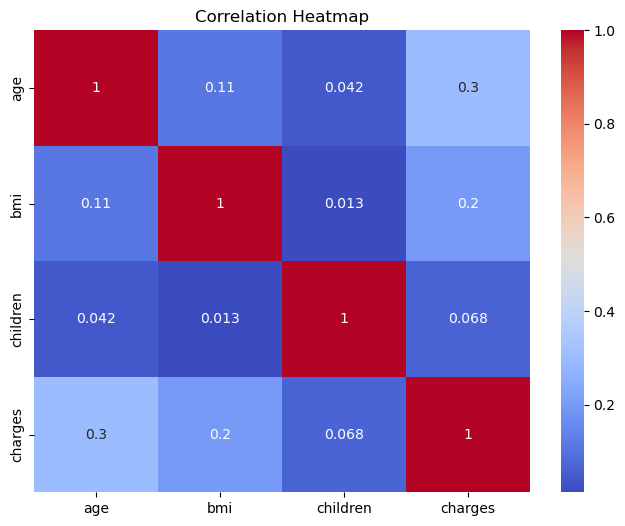

In [27]:
# Task 12: Heatmap

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("insurance.csv")

corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

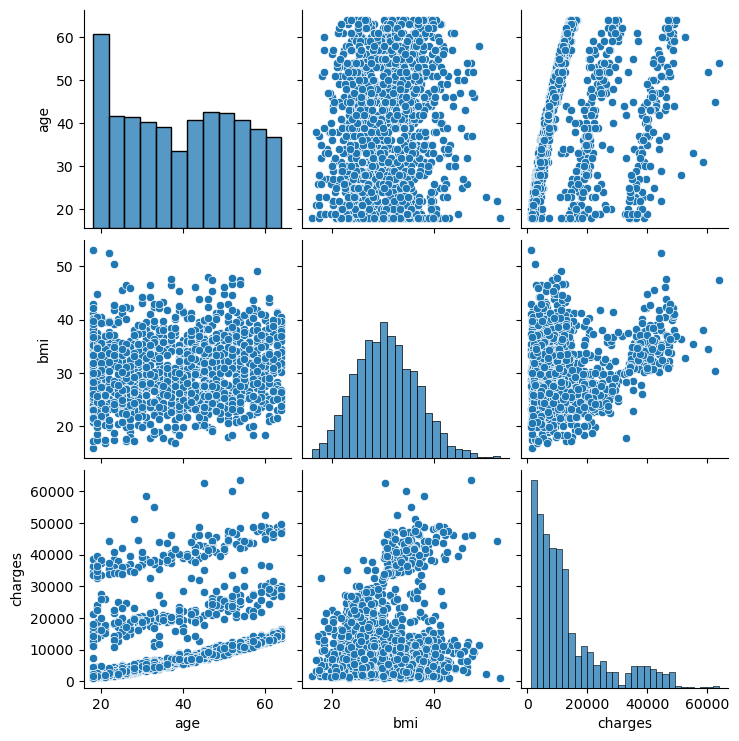

In [29]:
# Task 13: Pairplot

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("insurance.csv")

sns.pairplot(df[['age', 'bmi', 'charges']])
plt.show()

In [31]:
# Task 14: Skewness

import pandas as pd

df = pd.read_csv("insurance.csv")

print(df.skew(numeric_only=True))

age         0.055673
bmi         0.284047
children    0.938380
charges     1.515880
dtype: float64


In [61]:
# Task 15: Logistic Regression Setup

import pandas as pd
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("insurance.csv")

# Create binary target
df['target'] = (df['charges'] > df['charges'].median()).astype(int)

# Encode categorical columns
le = LabelEncoder()
for col in ['sex', 'smoker', 'region']:
    df[col] = le.fit_transform(df[col])

X = df.drop(['charges', 'target'], axis=1)
y = df['target']

print(X.head())

   age  sex     bmi  children  smoker  region
0   19    0  27.900         0       1       3
1   18    1  33.770         1       0       2
2   28    1  33.000         3       0       2
3   33    1  22.705         0       0       1
4   32    1  28.880         0       0       1


In [59]:
# Task 16: Train-Test Split

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("insurance.csv")

df['target'] = (df['charges'] > df['charges'].median()).astype(int)

le = LabelEncoder()
for col in ['sex', 'smoker', 'region']:
    df[col] = le.fit_transform(df[col])

X = df.drop(['charges', 'target'], axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (1003, 6)
Test: (335, 6)


In [65]:
# Task 17: Logistic Regression Training

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression

df = pd.read_csv("insurance.csv")

df['target'] = (df['charges'] > df['charges'].median()).astype(int)

le = LabelEncoder()
for col in ['sex', 'smoker', 'region']:
    df[col] = le.fit_transform(df[col])

X = df.drop(['charges', 'target'], axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(y_pred[:10])

[1 0 1 0 1 0 0 1 0 1]


In [73]:
# Task 18: Accuracy Score

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

df = pd.read_csv("insurance.csv")

df['target'] = (df['charges'] > df['charges'].median()).astype(int)

le = LabelEncoder()
for col in ['sex', 'smoker', 'region']:
    df[col] = le.fit_transform(df[col])

X = df.drop(['charges', 'target'], axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8925373134328358


In [79]:
# Task 19: Confusion Matrix

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

df = pd.read_csv("insurance.csv")

df['target'] = (df['charges'] > df['charges'].median()).astype(int)

le = LabelEncoder()
for col in ['sex', 'smoker', 'region']:
    df[col] = le.fit_transform(df[col])

X = df.drop(['charges', 'target'], axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))

[[152  20]
 [ 16 147]]


In [85]:
# Task 20: Classification Report

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

df = pd.read_csv("insurance.csv")

df['target'] = (df['charges'] > df['charges'].median()).astype(int)

le = LabelEncoder()
for col in ['sex', 'smoker', 'region']:
    df[col] = le.fit_transform(df[col])

X = df.drop(['charges', 'target'], axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.88      0.89       172
           1       0.88      0.90      0.89       163

    accuracy                           0.89       335
   macro avg       0.89      0.89      0.89       335
weighted avg       0.89      0.89      0.89       335



In [93]:
# Task 21: Logistic Regression Scaling Comparison

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

df = pd.read_csv("insurance.csv")

df['target'] = (df['charges'] > df['charges'].median()).astype(int)

le = LabelEncoder()
for col in ['sex', 'smoker', 'region']:
    df[col] = le.fit_transform(df[col])

X = df.drop(['charges', 'target'], axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# Without scaling
model1 = LogisticRegression(max_iter=1000, random_state=42)
model1.fit(X_train, y_train)
pred1 = model1.predict(X_test)

# With scaling
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

model2 = LogisticRegression(max_iter=1000, random_state=42)
model2.fit(X_train_s, y_train)
pred2 = model2.predict(X_test_s)

print("Without scaling:", accuracy_score(y_test, pred1))
print("With scaling:", accuracy_score(y_test, pred2))

Without scaling: 0.8925373134328358
With scaling: 0.8955223880597015


In [97]:
# Task 22: k-NN (k=3)

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

df = pd.read_csv("insurance.csv")

df['target'] = (df['charges'] > df['charges'].median()).astype(int)

le = LabelEncoder()
for col in ['sex', 'smoker', 'region']:
    df[col] = le.fit_transform(df[col])

X = df.drop(['charges', 'target'], axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8029850746268656
